# 📊 Análise do Brasileirão

Projeto de análise exploratória de dados do Campeonato Brasileiro utilizando Python.

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append("../src")

from utils import (
    carregar_dados,
    padronizar_colunas,
    criar_variaveis_analiticas,
    calcular_ataques,
    calcular_defesas,
    resumo_resultados,
    media_gols
)

In [82]:
caminho_arquivo = "../data/raw/brasileirao.csv"

df = carregar_dados(caminho_arquivo)
df.head()

,ID,rodada,data,hora,mandante,visitante,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,mandante_Placar,visitante_Placar,mandante_Estado,visitante_Estado,arrecadacao
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN


In [83]:
df.columns.tolist()

['ID',
 'rodada',
 'data',
 'hora',
 'mandante',
 'visitante',
 'formacao_mandante',
 'formacao_visitante',
 'tecnico_mandante',
 'tecnico_visitante',
 'vencedor',
 'arena',
 'mandante_Placar',
 'visitante_Placar',
 'mandante_Estado',
 'visitante_Estado',
 'arrecadacao']

In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9165 entries, 0 to 9164
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  9165 non-null   int64  
 1   rodada              9165 non-null   int64  
 2   data                9165 non-null   str    
 3   hora                9165 non-null   str    
 4   mandante            9165 non-null   str    
 5   visitante           9165 non-null   str    
 6   formacao_mandante   4190 non-null   str    
 7   formacao_visitante  4190 non-null   str    
 8   tecnico_mandante    4555 non-null   str    
 9   tecnico_visitante   4555 non-null   str    
 10  vencedor            9165 non-null   str    
 11  arena               9165 non-null   str    
 12  mandante_Placar     9165 non-null   int64  
 13  visitante_Placar    9165 non-null   int64  
 14  mandante_Estado     9165 non-null   str    
 15  visitante_Estado    9165 non-null   str    
 16  arrecadacao      

In [85]:
df.columns.tolist()

['ID',
 'rodada',
 'data',
 'hora',
 'mandante',
 'visitante',
 'formacao_mandante',
 'formacao_visitante',
 'tecnico_mandante',
 'tecnico_visitante',
 'vencedor',
 'arena',
 'mandante_Placar',
 'visitante_Placar',
 'mandante_Estado',
 'visitante_Estado',
 'arrecadacao']

In [86]:
df = padronizar_colunas(df)
df.columns.tolist()

['ID',
 'matchday',
 'match_date',
 'hora',
 'home_team',
 'away_team',
 'formacao_mandante',
 'formacao_visitante',
 'tecnico_mandante',
 'tecnico_visitante',
 'vencedor',
 'arena',
 'home_goals',
 'away_goals',
 'mandante_Estado',
 'visitante_Estado',
 'arrecadacao']

In [87]:
df = criar_variaveis_analiticas(df)
df.head()

,ID,matchday,match_date,hora,home_team,away_team,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,home_goals,away_goals,mandante_Estado,visitante_Estado,arrecadacao,total_goals,match_result
0,1,1,29/03/2003,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN,6,Casa
1,2,1,29/03/2003,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN,2,Casa
2,3,1,30/03/2003,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN,2,Empate
3,4,1,30/03/2003,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN,4,Empate
4,5,1,30/03/2003,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN,2,Empate


## 📈 Média de gols por temporada

In [88]:
print("Quantidade de jogos:", len(df))
print("Média de gols por partida:", round(media_gols(df), 2))

Quantidade de jogos: 9165
Média de gols por partida: 2.56


In [89]:
resultados = resumo_resultados(df)
resultados

match_result
Casa      4550
Empate    2421
Fora      2194
Name: count, dtype: int64

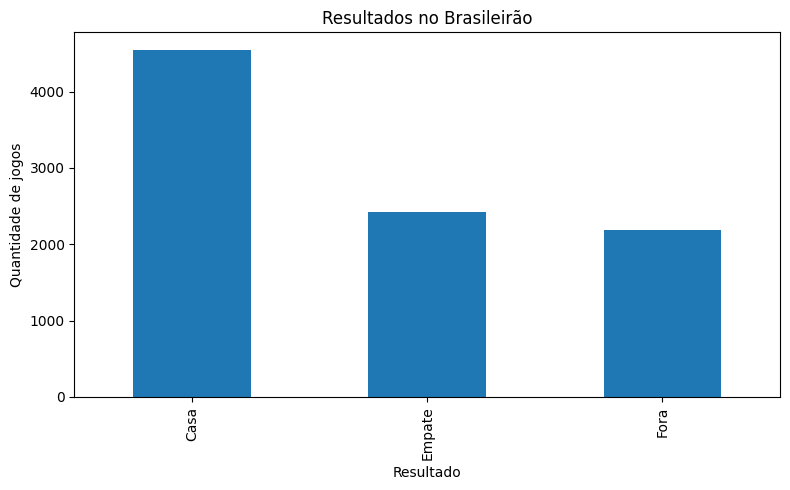

In [90]:
plt.figure(figsize=(8, 5))
resultados.plot(kind="bar")
plt.title("Resultados no Brasileirão")
plt.xlabel("Resultado")
plt.ylabel("Quantidade de jogos")
plt.tight_layout()
plt.show()

## ⚽ Ranking de ataques

In [91]:
ataques = calcular_ataques(df)
ataques.head(10)

home_team
Flamengo         1308
Sao Paulo        1259
Santos           1223
Atletico-MG      1221
Palmeiras        1203
Fluminense       1181
Internacional    1138
Cruzeiro         1111
Gremio           1110
Corinthians      1095
dtype: int64

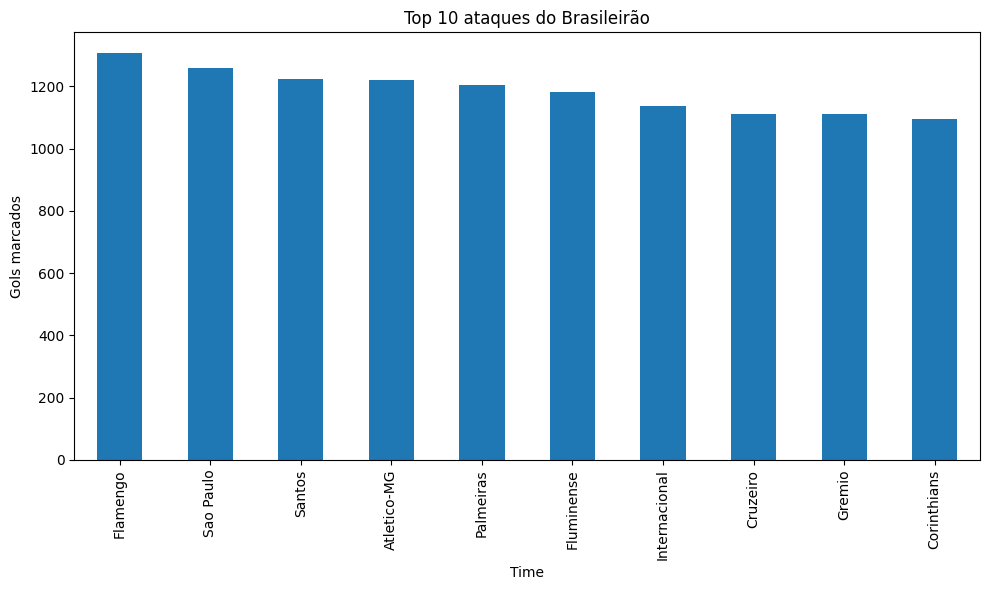

In [92]:
plt.figure(figsize=(10, 6))
ataques.head(10).plot(kind="bar")
plt.title("Top 10 ataques do Brasileirão")
plt.xlabel("Time")
plt.ylabel("Gols marcados")
plt.tight_layout()
plt.show()

## ⚠️ Observação sobre o ranking por total

Este ranking considera o total de gols sofridos ao longo do período analisado.

Esse critério pode favorecer equipes com menor número de participações no campeonato.

Por isso, a análise a seguir utiliza a média de gols sofridos por jogo, proporcionando uma comparação mais justa entre os clubes.

In [93]:
defesas = calcular_defesas(df)
defesas.head(10)

home_team
Mirassol            39
Joinville           48
Barueri             52
CSA                 58
Santo Andre         61
Gremio Prudente     64
Ipatinga            67
Brasiliense         68
America-RN          80
Santa Cruz         145
dtype: int64

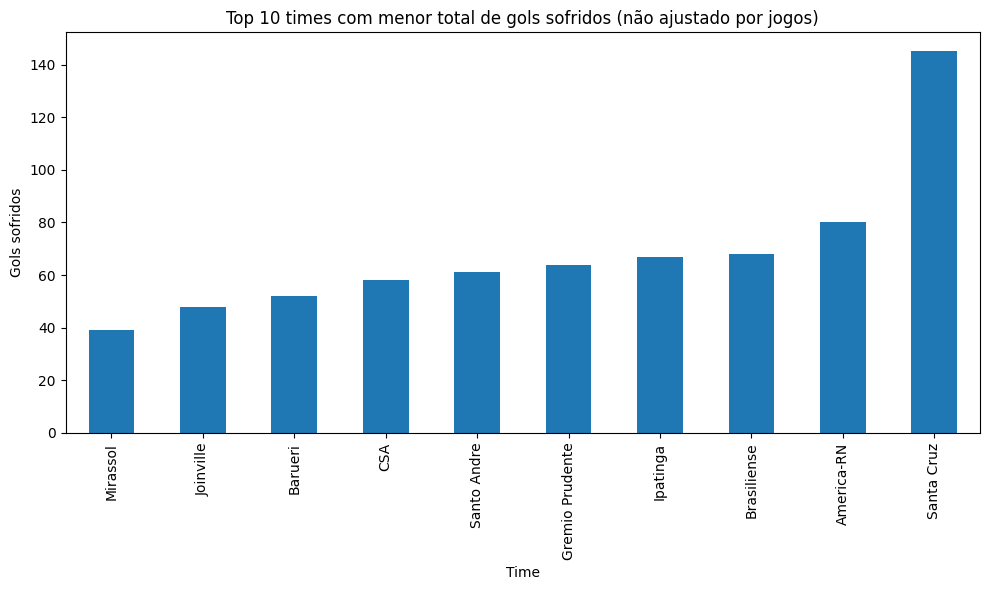

In [94]:
plt.figure(figsize=(10, 6))
defesas.head(10).plot(kind="bar")
plt.title("Top 10 times com menor total de gols sofridos (não ajustado por jogos)")
plt.xlabel("Time")
plt.ylabel("Gols sofridos")
plt.tight_layout()
plt.show()

## 🛡️ MELHORES DEFESAS (média por jogo + filtro)

In [105]:
# ==============================
# MELHORES DEFESAS (CORRIGIDO)
# ==============================

# Gols sofridos em casa
sofridos_casa = df.groupby("home_team")["away_goals"].sum()

# Gols sofridos fora
sofridos_fora = df.groupby("away_team")["home_goals"].sum()

# Total de gols sofridos
gols_sofridos_total = sofridos_casa.add(sofridos_fora, fill_value=0)

# Jogos em casa
jogos_casa = df.groupby("home_team").size()

# Jogos fora
jogos_fora = df.groupby("away_team").size()

# Total de jogos
jogos_total = jogos_casa.add(jogos_fora, fill_value=0)

# Criar DataFrame
ranking_defesas = pd.DataFrame({
    "gols_sofridos": gols_sofridos_total,
    "jogos": jogos_total
})

# Média de gols sofridos por jogo
ranking_defesas["media_sofridos"] = ranking_defesas["gols_sofridos"] / ranking_defesas["jogos"]

# 🔥 FILTRO IMPORTANTE (evita times pequenos com poucos jogos)
ranking_defesas = ranking_defesas[ranking_defesas["jogos"] >= 100]

# Ordenar (melhor defesa = menor média)
ranking_defesas = ranking_defesas.sort_values("media_sofridos")

ranking_defesas.head(10)

,gols_sofridos,jogos,media_sofridos
home_team,,,
Corinthians,924,856,1.079439
Sao Paulo,969,894,1.083893
Cuiaba,167,152,1.098684
Internacional,945,856,1.103972
Palmeiras,906,810,1.118519
Gremio,934,814,1.147420
Flamengo,1031,894,1.153244
Sao Caetano,199,172,1.156977
Ceara,357,304,1.174342


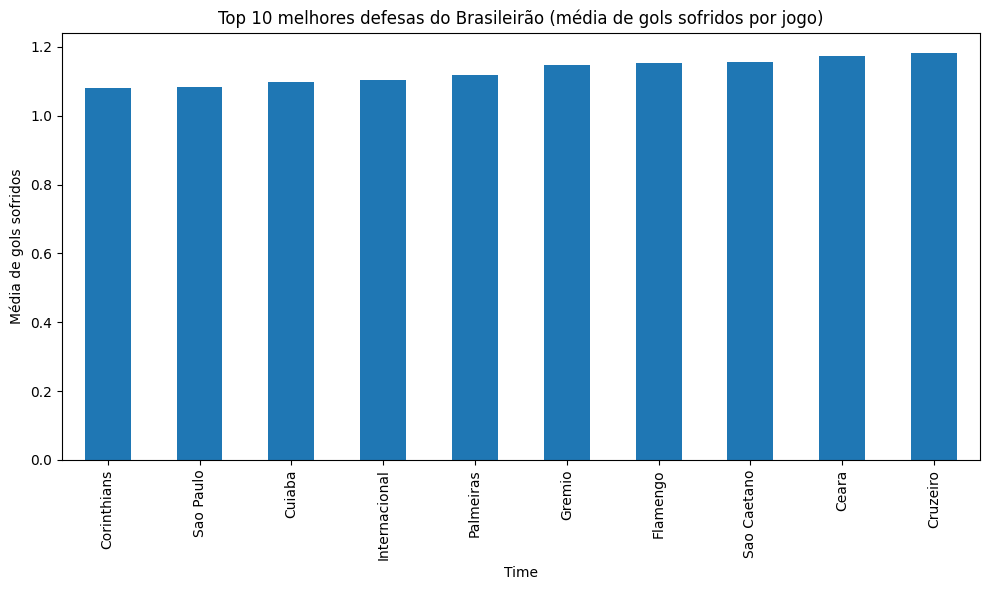

In [106]:
plt.figure(figsize=(10,6))
ranking_defesas["media_sofridos"].head(10).plot(kind="bar")

plt.title("Top 10 melhores defesas do Brasileirão (média de gols sofridos por jogo)")
plt.xlabel("Time")
plt.ylabel("Média de gols sofridos")

plt.tight_layout()

plt.savefig("../images/melhores_defesas.png")
plt.show()

## 📌 Metodologia

Para evitar distorções na análise, foi utilizada a média de gols por jogo ao invés do total acumulado.

Além disso, foi aplicado um filtro mínimo de 100 jogos disputados por equipe, garantindo uma comparação mais justa entre os clubes.

Isso evita que equipes com poucas participações apareçam de forma indevida nos rankings.

## ⚽ MELHORES ATAQUES (média por jogo + filtro)

In [107]:
# ==============================
# MELHORES ATAQUES (CORRIGIDO)
# ==============================

# Gols marcados em casa
gols_casa = df.groupby("home_team")["home_goals"].sum()

# Gols marcados fora
gols_fora = df.groupby("away_team")["away_goals"].sum()

# Total de gols marcados
gols_marcados_total = gols_casa.add(gols_fora, fill_value=0)

# Criar DataFrame
ranking_ataques = pd.DataFrame({
    "gols_marcados": gols_marcados_total,
    "jogos": jogos_total  # já calculado antes
})

# Média de gols por jogo
ranking_ataques["media_gols"] = ranking_ataques["gols_marcados"] / ranking_ataques["jogos"]

# 🔥 FILTRO IMPORTANTE
ranking_ataques = ranking_ataques[ranking_ataques["jogos"] >= 100]

# Ordenar (melhor ataque = maior média)
ranking_ataques = ranking_ataques.sort_values("media_gols", ascending=False)

ranking_ataques.head(10)

,gols_marcados,jogos,media_gols
home_team,,,
Palmeiras,1203,810,1.485185
Flamengo,1308,894,1.463087
Paysandu,193,134,1.440299
Santos,1223,856,1.428738
Atletico-MG,1221,855,1.428070
Cruzeiro,1111,780,1.424359
Sao Paulo,1259,894,1.408277
Gremio,1110,814,1.363636
Goias,789,590,1.337288


In [108]:
# ==============================
# MELHORES ATAQUES (CORRIGIDO)
# ==============================

# Gols marcados em casa
gols_casa = df.groupby("home_team")["home_goals"].sum()

# Gols marcados fora
gols_fora = df.groupby("away_team")["away_goals"].sum()

# Total de gols marcados
gols_marcados_total = gols_casa.add(gols_fora, fill_value=0)

# Criar DataFrame
ranking_ataques = pd.DataFrame({
    "gols_marcados": gols_marcados_total,
    "jogos": jogos_total  # já calculado antes
})

# Média de gols por jogo
ranking_ataques["media_gols"] = ranking_ataques["gols_marcados"] / ranking_ataques["jogos"]

# 🔥 FILTRO IMPORTANTE
ranking_ataques = ranking_ataques[ranking_ataques["jogos"] >= 100]

# Ordenar (melhor ataque = maior média)
ranking_ataques = ranking_ataques.sort_values("media_gols", ascending=False)

ranking_ataques.head(10)

,gols_marcados,jogos,media_gols
home_team,,,
Palmeiras,1203,810,1.485185
Flamengo,1308,894,1.463087
Paysandu,193,134,1.440299
Santos,1223,856,1.428738
Atletico-MG,1221,855,1.428070
Cruzeiro,1111,780,1.424359
Sao Paulo,1259,894,1.408277
Gremio,1110,814,1.363636
Goias,789,590,1.337288


In [95]:
df["match_date"] = pd.to_datetime(df["match_date"],dayfirst=True)

df["season"] = df["match_date"].dt.year

df.head()

,ID,matchday,match_date,hora,home_team,away_team,formacao_mandante,formacao_visitante,tecnico_mandante,tecnico_visitante,vencedor,arena,home_goals,away_goals,mandante_Estado,visitante_Estado,arrecadacao,total_goals,match_result,season
0,1,1,2003-03-29,16:00,Guarani,Vasco,NaN,NaN,NaN,NaN,Guarani,Brinco de Ouro,4,2,SP,RJ,NaN,6,Casa,2003
1,2,1,2003-03-29,16:00,Athletico-PR,Gremio,NaN,NaN,NaN,NaN,Athletico-PR,Arena da Baixada,2,0,PR,RS,NaN,2,Casa,2003
2,3,1,2003-03-30,16:00,Flamengo,Coritiba,NaN,NaN,NaN,NaN,-,Maracanã,1,1,RJ,PR,NaN,2,Empate,2003
3,4,1,2003-03-30,16:00,Goias,Paysandu,NaN,NaN,NaN,NaN,-,Serra Dourada,2,2,GO,PA,NaN,4,Empate,2003
4,5,1,2003-03-30,16:00,Internacional,Ponte Preta,NaN,NaN,NaN,NaN,-,Beira Rio,1,1,RS,SP,NaN,2,Empate,2003


In [96]:
df["season"].unique()

array([2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013,
       2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024,
       2025], dtype=int32)

In [97]:
media_por_temporada = df.groupby("season")["total_goals"].mean().sort_index()
media_por_temporada

season
2003    2.884058
2004    2.778986
2005    3.140693
2006    2.710526
2007    2.755263
2008    2.723684
2009    2.878947
2010    2.573684
2011    2.676316
2012    2.473684
2013    2.463158
2014    2.263158
2015    2.360526
2016    2.406332
2017    2.428947
2018    2.176316
2019    2.305263
2020    2.440299
2021    2.300813
2022    2.381579
2023    2.489474
2024    2.444737
2025    2.523684
Name: total_goals, dtype: float64

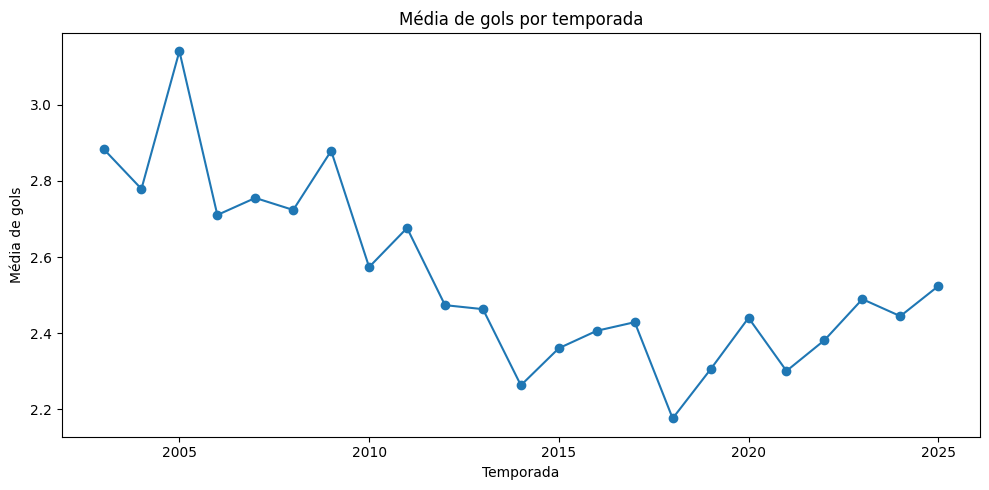

In [98]:
if "season" in df.columns:
    plt.figure(figsize=(10, 5))
    media_por_temporada.plot(kind="line", marker="o")
    plt.title("Média de gols por temporada")
    plt.xlabel("Temporada")
    plt.ylabel("Média de gols")
    plt.tight_layout()
    plt.show()

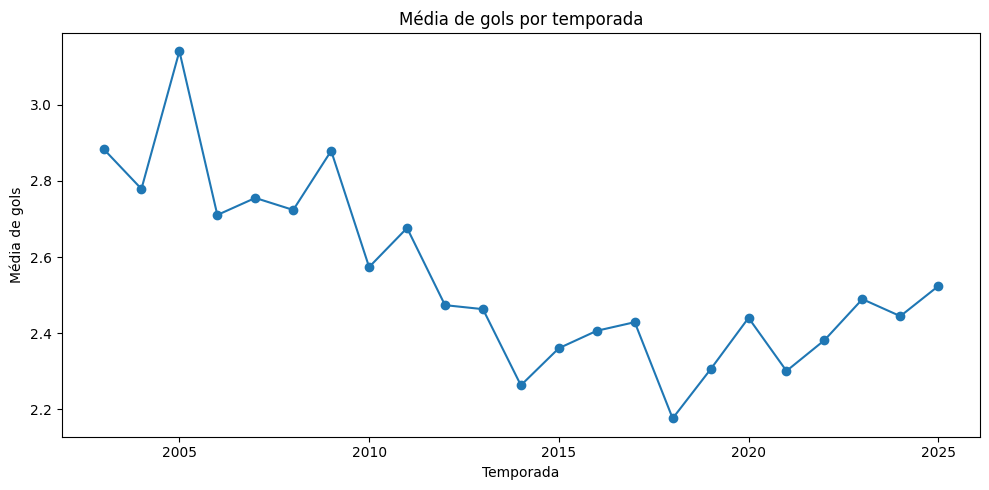

In [99]:
plt.figure(figsize=(10, 5))
media_por_temporada.plot(kind="line", marker="o")
plt.title("Média de gols por temporada")
plt.xlabel("Temporada")
plt.ylabel("Média de gols")

plt.tight_layout()

plt.savefig("../images/media_gols_temporada.png")
plt.show()

In [100]:
top_ataque_por_ano = (
    df.groupby(["season", "home_team"])["home_goals"].sum()
    .reset_index()
    .sort_values(["season", "home_goals"], ascending=[True, False])
)

top_ataque_por_ano = top_ataque_por_ano.groupby("season").first()

top_ataque_por_ano.head(10)

,home_team,home_goals
season,,
2003,Cruzeiro,61
2004,Santos,64
2005,Athletico-PR,49
2006,Gremio,40
2007,Cruzeiro,43
2008,Flamengo,42
2009,Gremio,53
2010,Corinthians,41
2011,Coritiba,40


In [101]:
df["gols_sofridos"] = df["away_goals"]

top_defesa_por_ano = (
    df.groupby(["season", "home_team"])["gols_sofridos"].sum()
    .reset_index()
    .sort_values(["season", "gols_sofridos"], ascending=[True, True])
)

top_defesa_por_ano = top_defesa_por_ano.groupby("season").first()

top_defesa_por_ano.head(10)

,home_team,gols_sofridos
season,,
2003,Sao Caetano,14
2004,Flamengo,17
2005,Internacional,22
2006,Santos,12
2007,Sao Paulo,8
2008,Gremio,10
2009,Flamengo,11
2010,Ceara,12
2011,Vasco,12


In [102]:
top_defesa_por_ano.to_csv("../data/processed/melhores_defesas_por_ano.csv")

In [103]:
top_ataque_por_ano.to_csv("../data/processed/melhores_ataques_por_ano.csv")

## 📊 Jogos por temporada

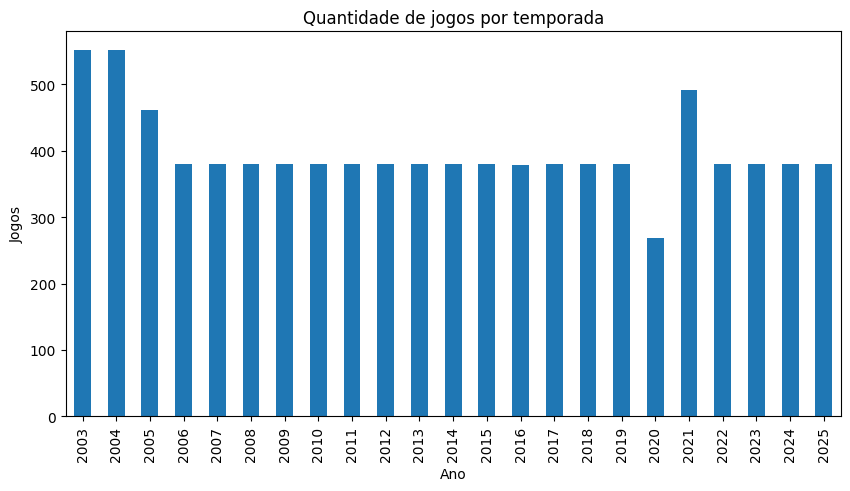

In [104]:
jogos_por_ano = df.groupby("season").size()

plt.figure(figsize=(10,5))
jogos_por_ano.plot(kind="bar")

plt.title("Quantidade de jogos por temporada")
plt.xlabel("Ano")
plt.ylabel("Jogos")

plt.show()

## Insights principais

- Observa-se uma queda na média de gols entre 2012 e 2018
- Há uma recuperação gradual após 2020
- Times com melhores defesas variam ao longo dos anos, mostrando equilíbrio competitivo
- O Brasileirão apresenta mudanças de padrão ao longo do tempo
- Em 2003 foi o ano com mais gols marcados.